# Gen 2.2 Linear Model

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

Accuracy: 91.11111111111111


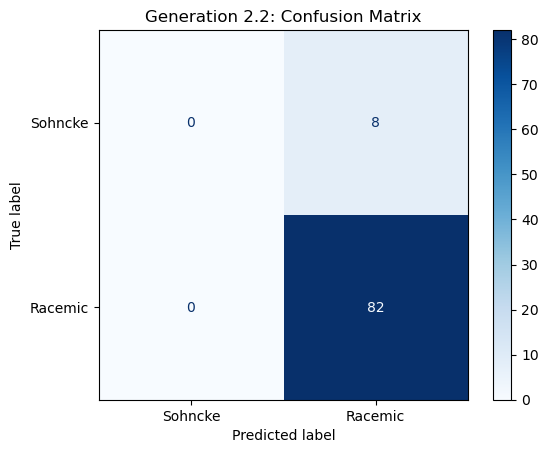

In [6]:
df = pd.read_csv(r'filtered and normalised all descriptor data.csv') # Pulling the data and creating a dataframe

df = df.drop(columns=['Refcode', 'Point group']) # Cleaning the database and getting rid of any rows that aren't 'float64'

X = df.drop(columns='Target') # Creating a new dataframe without the sohncke/racemic answers
y = df['Target'] # Creating a new dataframe with just the sohncke/racemic answers

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3) # Generating the training and testing data with a 70/30 split

logreg = LogisticRegression() # Storing the logistical model
logreg.fit(X_train, y_train) # Training the logistical model

y_predict = logreg.predict(X_test) # Predicting sohncke/racemic with the new model

print("Accuracy:",metrics.accuracy_score(y_test, y_predict)*100) # Printing out the accuracy

# Outputting the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    logreg, 
    X_test, 
    y_test, 
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
);
plt.title('Generation 2.2: Confusion Matrix');


---

# Average over 100 runs

---

## Unbalanced

In [ ]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# Load the data
list_path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list_path)

# Clean the data
df_cleaned = df.drop(columns=['Point group', 'Refcode'])
feature_df = df_cleaned.drop(columns=['Target'])

# Convert to numpy arrays
X = np.asarray(feature_df)
y = np.asarray(df_cleaned['Target'])

# Initialize variables to store results
accuracies = []
confusion_matrices = []

# Run the model 100 times
for _ in range(100):
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
    
    logreg = LogisticRegression() # Storing the logistical model
    logreg.fit(X_train, y_train) # Training the logistical model

    y_predict = logreg.predict(X_test) # Predicting sohncke/racemic with the new model
    
    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_predict)
    confusion_matrices.append(cm)

    print(f'Run {_+1} completed with accuracy: {accuracy}')

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Find the best confusion matrix (highest accuracy)
best_accuracy_index = np.argmax(accuracies)
best_confusion_matrix = confusion_matrices[best_accuracy_index]
best_accuracy = accuracies[best_accuracy_index]

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(confusion_matrices, axis=0)

# Display the best confusion matrix
ConfusionMatrixDisplay(best_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'LogReg: Best Confusion Matrix [Accuracy: {best_accuracy:.2f}%]')
plt.show()

# Display the average confusion matrix
ConfusionMatrixDisplay(average_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('LogReg: Average Confusion Matrix')
plt.show()

# Print the average accuracy
print(f"Average Accuracy over 100 runs: {average_accuracy:.2f}%")

## Balanced

Run 1 completed with accuracy: 65.38461538461539
Run 2 completed with accuracy: 61.53846153846154
Run 3 completed with accuracy: 61.53846153846154
Run 4 completed with accuracy: 65.38461538461539
Run 5 completed with accuracy: 38.46153846153847
Run 6 completed with accuracy: 42.30769230769231
Run 7 completed with accuracy: 65.38461538461539
Run 8 completed with accuracy: 50.0
Run 9 completed with accuracy: 53.84615384615385
Run 10 completed with accuracy: 53.84615384615385
Run 11 completed with accuracy: 53.84615384615385
Run 12 completed with accuracy: 65.38461538461539
Run 13 completed with accuracy: 42.30769230769231
Run 14 completed with accuracy: 61.53846153846154
Run 15 completed with accuracy: 53.84615384615385
Run 16 completed with accuracy: 50.0
Run 17 completed with accuracy: 38.46153846153847
Run 18 completed with accuracy: 38.46153846153847
Run 19 completed with accuracy: 50.0
Run 20 completed with accuracy: 38.46153846153847
Run 21 completed with accuracy: 57.6923076923076

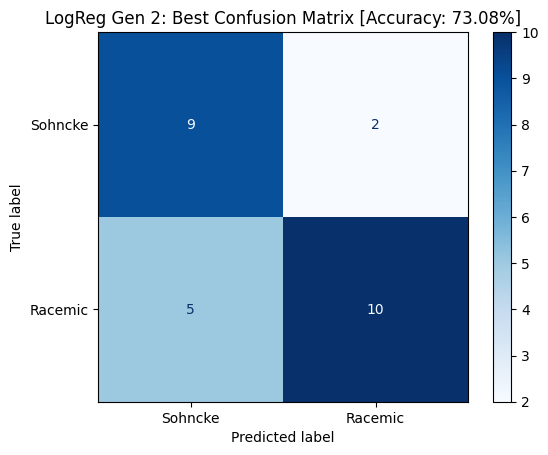

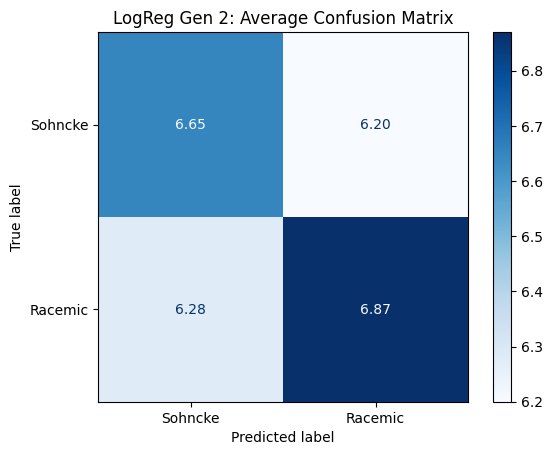

Average Accuracy over 100 runs: 52.00%


In [6]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
import pickle  # Import pickle for saving the model

# Load the data
list_path = r'filtered and normalised all descriptor data.csv'

# Initialize variables to store results
accuracies = []
confusion_matrices = []
models = []  # List to store models

# Run the model 100 times
for _ in range(100):

    # Load the data
    df = pd.read_csv(list_path)

    # Balance the dataset
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    
    if len(df_target_0) < len(df_target_1):
        smaller_df = df_target_0
        larger_df = df_target_1
    else:
        smaller_df = df_target_1
        larger_df = df_target_0

    scaled_larger_df = larger_df.sample(n=len(smaller_df))  # Sample to balance the dataset
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0).sample(frac=1).reset_index(drop=True)

    # Clean the data
    cleaned_df = balanced_df.drop(columns=['Point group', 'Refcode'])

    # Separate features and target
    X = np.asarray(cleaned_df.drop(columns=['Target']))
    y = np.asarray(cleaned_df['Target'])

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
    
    logreg = LogisticRegression() # Storing the logistical model
    logreg.fit(X_train, y_train) # Training the logistical model

    y_predict = logreg.predict(X_test) # Predicting sohncke/racemic with the new model
    
    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_predict)
    confusion_matrices.append(cm)
    
    # Store the model
    models.append(logreg)
    
    print(f'Run {_+1} completed with accuracy: {accuracy}')

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Find the best model (highest accuracy)
best_accuracy_index = np.argmax(accuracies)
best_model = models[best_accuracy_index]
best_confusion_matrix = confusion_matrices[best_accuracy_index]
best_accuracy = accuracies[best_accuracy_index]

# Save the best model as a .pkl file using pickle
pkl_file = "best_logistic_regression_model.pkl"
with open(pkl_file, 'wb') as file:
    pickle.dump(best_model, file)
print(f"Best model saved as {pkl_file}")

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(confusion_matrices, axis=0)

# Display the best confusion matrix
ConfusionMatrixDisplay(best_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'LogReg Gen 2: Best Confusion Matrix [Accuracy: {best_accuracy:.2f}%]')
plt.show()

# Display the average confusion matrix
ConfusionMatrixDisplay(average_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('LogReg Gen 2: Average Confusion Matrix')
plt.show()

# Print the average accuracy
print(f"Average Accuracy over 100 runs: {average_accuracy:.2f}%")


---
# Getting the highest accuracy model (95.56%)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

Accuracy of the current model: 90.00%
Accuracy of the current model: 84.44%
Accuracy of the current model: 83.33%
Accuracy of the current model: 85.56%
Accuracy of the current model: 93.33%
Accuracy of the current model: 90.00%
Accuracy of the current model: 88.89%
Accuracy of the current model: 84.44%
Accuracy of the current model: 84.44%
Accuracy of the current model: 83.33%
Accuracy of the current model: 90.00%
Accuracy of the current model: 86.67%
Accuracy of the current model: 82.22%
Accuracy of the current model: 83.33%
Accuracy of the current model: 88.89%
Accuracy of the current model: 86.67%
Accuracy of the current model: 81.11%
Accuracy of the current model: 86.67%
Accuracy of the current model: 90.00%
Accuracy of the current model: 87.78%
Accuracy of the current model: 80.00%
Accuracy of the current model: 82.22%
Accuracy of the current model: 85.56%
Accuracy of the current model: 81.11%
Accuracy of the current model: 83.33%
Accuracy of the current model: 93.33%
Accuracy of 

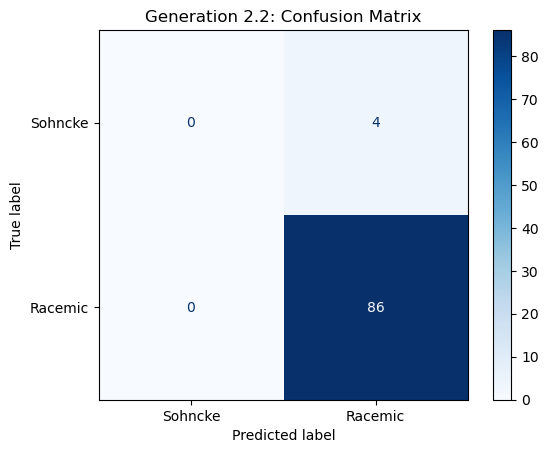

Model saved to best_svc_model_94_acc_gen_2_2.pkl


In [12]:
df = pd.read_csv(r'filtered and normalised all descriptor data.csv') # Pulling the data and creating a dataframe

df = df.drop(columns=['Refcode', 'Point group']) # Cleaning the database and getting rid of any rows that aren't 'float64'

X = df.drop(columns='Target') # Creating a new dataframe without the sohncke/racemic answers
y = df['Target'] # Creating a new dataframe with just the sohncke/racemic answers

# Loop until the accuracy is above 90%
accuracy = 0
while accuracy < 95:

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3) # Generating the training and testing data with a 70/30 split

    logreg = LogisticRegression() # Storing the logistical model
    logreg.fit(X_train, y_train) # Training the logistical model

    y_predict = logreg.predict(X_test) # Predicting sohncke/racemic with the new model

    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    print(f"Accuracy of the current model: {accuracy:.2f}%")
    
    if accuracy >= 95:
        
        # Outputting the confusion matrix
        ConfusionMatrixDisplay.from_estimator(
            logreg, 
            X_test, 
            y_test, 
            display_labels=["Sohncke", "Racemic"],
            cmap=plt.cm.Blues,
            values_format='d'
        );
        plt.title('Generation 2.2: Confusion Matrix');
        plt.show()
        
        # Save the model
        joblib_file = "best_svc_model_94_acc_gen_2_2.pkl"
        joblib.dump(logreg, joblib_file)
        print(f"Model saved to {joblib_file}")


Accuracy: 46.15384615384615


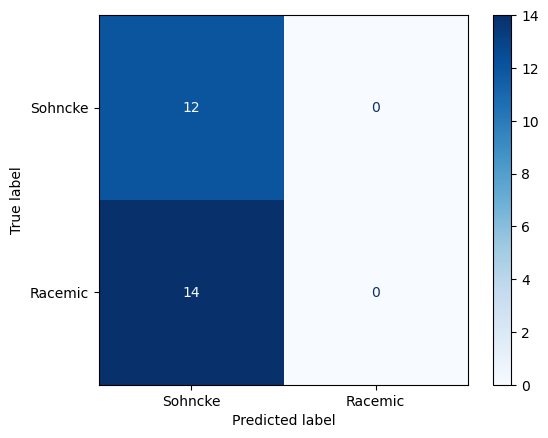

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

df = pd.read_csv(r'filtered and normalised all descriptor data.csv')
df_target_0 = df[df['Target'] == 0.0]
df_target_1 = df[df['Target'] == 1.0]
rows_df_target_0 = df_target_0.shape[0]
rows_df_target_1 = df_target_1.shape[0]

if rows_df_target_0 < rows_df_target_1:
    smaller_df = df_target_0
    larger_df = df_target_1
    smaller_rows = rows_df_target_0
else:
    smaller_df = df_target_1
    larger_df = df_target_0
    smaller_rows = rows_df_target_1

scaled_larger_df = larger_df.sample(n=smaller_rows)
balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode'])
feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
X = np.asarray(feature_df)
y = np.asarray(shuffled_balanced_cleaned_df['Target'])
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.30)
logreg = LogisticRegression(C=1)
logreg.fit(X_train, y_train)
y_predict = logreg.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_predict)*100)

ConfusionMatrixDisplay.from_estimator(
    logreg, 
    X_test, 
    y_test, 
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
);

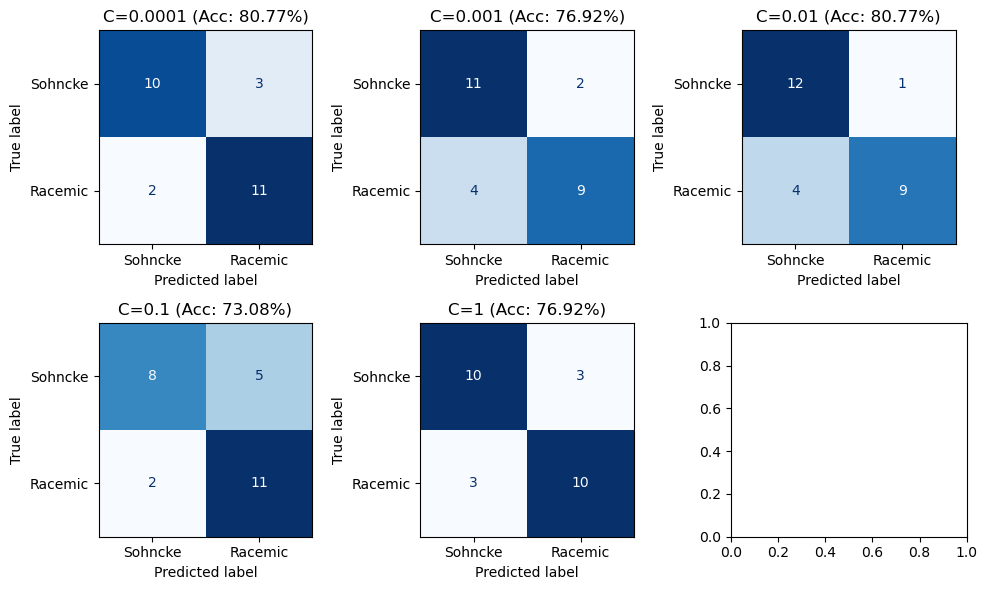

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

# Load data
df = pd.read_csv(r'filtered and normalised all descriptor data.csv')
df_target_0 = df[df['Target'] == 0.0]
df_target_1 = df[df['Target'] == 1.0]
rows_df_target_0 = df_target_0.shape[0]
rows_df_target_1 = df_target_1.shape[0]

# Determine smaller and larger class dataframes
if rows_df_target_0 < rows_df_target_1:
    smaller_df = df_target_0
    larger_df = df_target_1
    smaller_rows = rows_df_target_0
else:
    smaller_df = df_target_1
    larger_df = df_target_0
    smaller_rows = rows_df_target_1

c_list = [1e-4, 1e-3, 1e-2, 1e-1, 1]
best_confusion_matrices = []

for c_value in c_list:
    best_accuracy = 0
    best_confusion_matrix = None
    
    for i in range(1000):
        # Balance the dataset
        scaled_larger_df = larger_df.sample(n=smaller_rows)
        balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
        shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
        shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode'])
        feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
        X = np.asarray(feature_df)
        y = np.asarray(shuffled_balanced_cleaned_df['Target'])
        
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
        
        # Train and evaluate the model
        logreg = LogisticRegression(C=c_value)
        logreg.fit(X_train, y_train)
        y_predict = logreg.predict(X_test)
        accuracy = metrics.accuracy_score(y_test, y_predict) * 100
        
        # Track the best model for this C value
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_confusion_matrix = metrics.confusion_matrix(y_test, y_predict)
    
    # Store the best confusion matrix for this C value
    best_confusion_matrices.append((best_confusion_matrix, best_accuracy, c_value))

# Plot the confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, (matrix, accuracy, c_value) in enumerate(best_confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["Sohncke", "Racemic"])
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=axes[i], colorbar=False)
    axes[i].set_title(f'C={c_value} (Acc: {accuracy:.2f}%)')

# Adjust layout
plt.tight_layout()
plt.show()


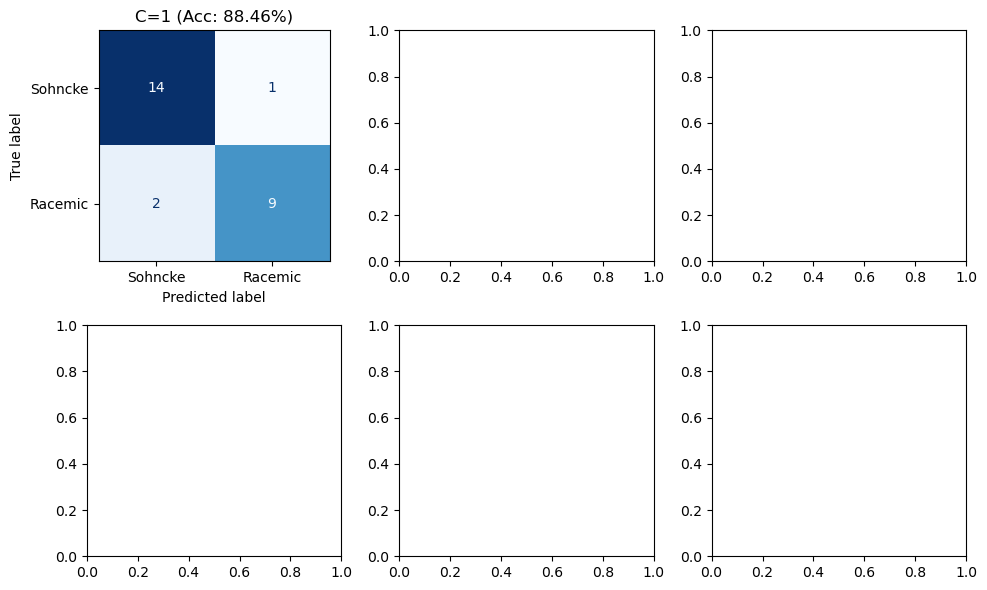

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

# Load data
df = pd.read_csv(r'filtered and normalised all descriptor data.csv')
df_target_0 = df[df['Target'] == 0.0]
df_target_1 = df[df['Target'] == 1.0]
rows_df_target_0 = df_target_0.shape[0]
rows_df_target_1 = df_target_1.shape[0]

# Determine smaller and larger class dataframes
if rows_df_target_0 < rows_df_target_1:
    smaller_df = df_target_0
    larger_df = df_target_1
    smaller_rows = rows_df_target_0
else:
    smaller_df = df_target_1
    larger_df = df_target_0
    smaller_rows = rows_df_target_1

c_list = [1]
best_confusion_matrices = []
best_model = None

for c_value in c_list:
    best_accuracy = 0
    best_confusion_matrix = None
    
    # Iterate 10000 times for c_value = 1
    iterations = 10000 if c_value == 1 else 100
    for i in range(iterations):
        # Balance the dataset
        scaled_larger_df = larger_df.sample(n=smaller_rows)
        balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
        shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
        shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode'])
        feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
        X = np.asarray(feature_df)
        y = np.asarray(shuffled_balanced_cleaned_df['Target'])
        
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
        
        # Train and evaluate the model
        logreg = LogisticRegression(C=c_value)
        logreg.fit(X_train, y_train)
        y_predict = logreg.predict(X_test)
        accuracy = metrics.accuracy_score(y_test, y_predict) * 100
        
        # Track the best model for this C value
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_confusion_matrix = metrics.confusion_matrix(y_test, y_predict)
            best_model = logreg  # Save the best model
    
    # Store the best confusion matrix for this C value
    best_confusion_matrices.append((best_confusion_matrix, best_accuracy, c_value))

# Save the best model for C=1 to a .pkl file
joblib.dump(best_model, 'best_model_c1.pkl')

# Plot the confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, (matrix, accuracy, c_value) in enumerate(best_confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["Sohncke", "Racemic"])
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=axes[i], colorbar=False)
    axes[i].set_title(f'C={c_value} (Acc: {accuracy:.2f}%)')

# Adjust layout
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'logreg__C': 10, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
Test Set Accuracy: 0.77
              precision    recall  f1-score   support

         0.0       0.91      0.67      0.77        15
         1.0       0.67      0.91      0.77        11

    accuracy                           0.77        26
   macro avg       0.79      0.79      0.77        26
weighted avg       0.81      0.77      0.77        26



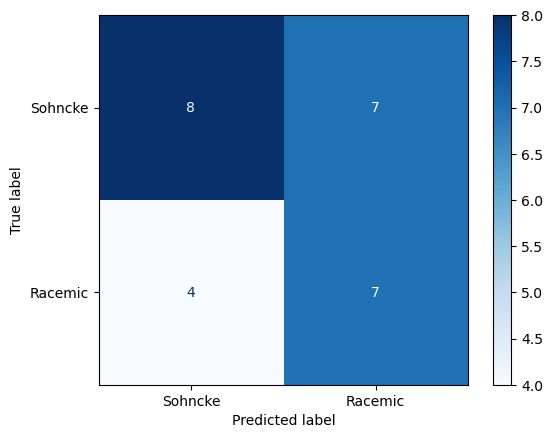

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv(r'filtered and normalised all descriptor data.csv')
df_target_0 = df[df['Target'] == 0.0]
df_target_1 = df[df['Target'] == 1.0]
rows_df_target_0 = df_target_0.shape[0]
rows_df_target_1 = df_target_1.shape[0]

if rows_df_target_0 < rows_df_target_1:
    smaller_df = df_target_0
    larger_df = df_target_1
    smaller_rows = rows_df_target_0
else:
    smaller_df = df_target_1
    larger_df = df_target_0
    smaller_rows = rows_df_target_1

scaled_larger_df = larger_df.sample(n=smaller_rows)
balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode'])
feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
X = np.asarray(feature_df)
y = np.asarray(shuffled_balanced_cleaned_df['Target'])
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.30)

# Define the model pipeline with scaling
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=10000))
])

# Define the parameter grid
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l2'],  # You can also try 'l1' if the solver supports it
    'logreg__solver': ['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best parameters and estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

# Print the best parameters
print(f"Best Parameters: {best_params}")

# Evaluate the model on the test set
y_pred = best_estimator.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    logreg, 
    X_test, 
    y_test, 
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
);


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv(r'filtered and normalised all descriptor data.csv')
df_target_0 = df[df['Target'] == 0.0]
df_target_1 = df[df['Target'] == 1.0]
rows_df_target_0 = df_target_0.shape[0]
rows_df_target_1 = df_target_1.shape[0]

if rows_df_target_0 < rows_df_target_1:
    smaller_df = df_target_0
    larger_df = df_target_1
    smaller_rows = rows_df_target_0
else:
    smaller_df = df_target_1
    larger_df = df_target_0
    smaller_rows = rows_df_target_1

for i in range(10):
    scaled_larger_df = larger_df.sample(n=smaller_rows)
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
    shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
    shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode'])
    feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
    X = np.asarray(feature_df)
    y = np.asarray(shuffled_balanced_cleaned_df['Target'])
    X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.30)

    # Define the model pipeline with scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=10000))
    ])

    # Define the parameter grid
    param_grid = {
        'logreg__C': [0.01, 0.1, 1, 10, 100],
        'logreg__penalty': ['l2'],  # You can also try 'l1' if the solver supports it
        'logreg__solver': ['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga']
    }

    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='accuracy',
        verbose=1
    )

    # Fit GridSearchCV
    grid_search.fit(X_train, y_train)

    # Get the best parameters and estimator
    best_params = grid_search.best_params_
    best_estimator = grid_search.best_estimator_

    # Print the best parameters
    print(f"Best Parameters: {best_params}")

    # Evaluate the model on the test set
    y_pred = best_estimator.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Set Accuracy: {accuracy:.2f}")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_estimator(
        logreg, 
        X_test, 
        y_test, 
        display_labels=["Sohncke", "Racemic"],
        cmap=plt.cm.Blues,
        values_format='d'
    );


Iteration 1:
Best Parameters: {'logreg__C': 0.1, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Test Set Accuracy: 0.50
              precision    recall  f1-score   support

         0.0       0.53      0.57      0.55        14
         1.0       0.45      0.42      0.43        12

    accuracy                           0.50        26
   macro avg       0.49      0.49      0.49        26
weighted avg       0.50      0.50      0.50        26

Iteration 2:
Best Parameters: {'logreg__C': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'sag'}
Test Set Accuracy: 0.35
              precision    recall  f1-score   support

         0.0       0.33      0.21      0.26        14
         1.0       0.35      0.50      0.41        12

    accuracy                           0.35        26
   macro avg       0.34      0.36      0.34        26
weighted avg       0.34      0.35      0.33        26

Iteration 3:
Best Parameters: {'logreg__C': 0.1, 'logreg__penalty': 'l2', 'logreg__solver': 'libli

/Users/leoarogundade/anaconda3/envs/chem-main/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/leoarogundade/anaconda3/envs/chem-main/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/leoarogundade/anaconda3/envs/chem-main/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

Iteration 5:
Best Parameters: {'logreg__C': 0.01, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
Test Set Accuracy: 0.62
              precision    recall  f1-score   support

         0.0       0.62      0.62      0.62        13
         1.0       0.62      0.62      0.62        13

    accuracy                           0.62        26
   macro avg       0.62      0.62      0.62        26
weighted avg       0.62      0.62      0.62        26

Iteration 6:
Best Parameters: {'logreg__C': 0.01, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Test Set Accuracy: 0.31
              precision    recall  f1-score   support

         0.0       0.36      0.27      0.31        15
         1.0       0.27      0.36      0.31        11

    accuracy                           0.31        26
   macro avg       0.32      0.32      0.31        26
weighted avg       0.32      0.31      0.31        26

Iteration 7:
Best Parameters: {'logreg__C': 100, 'logreg__penalty': 'l2', 'logreg__solver'

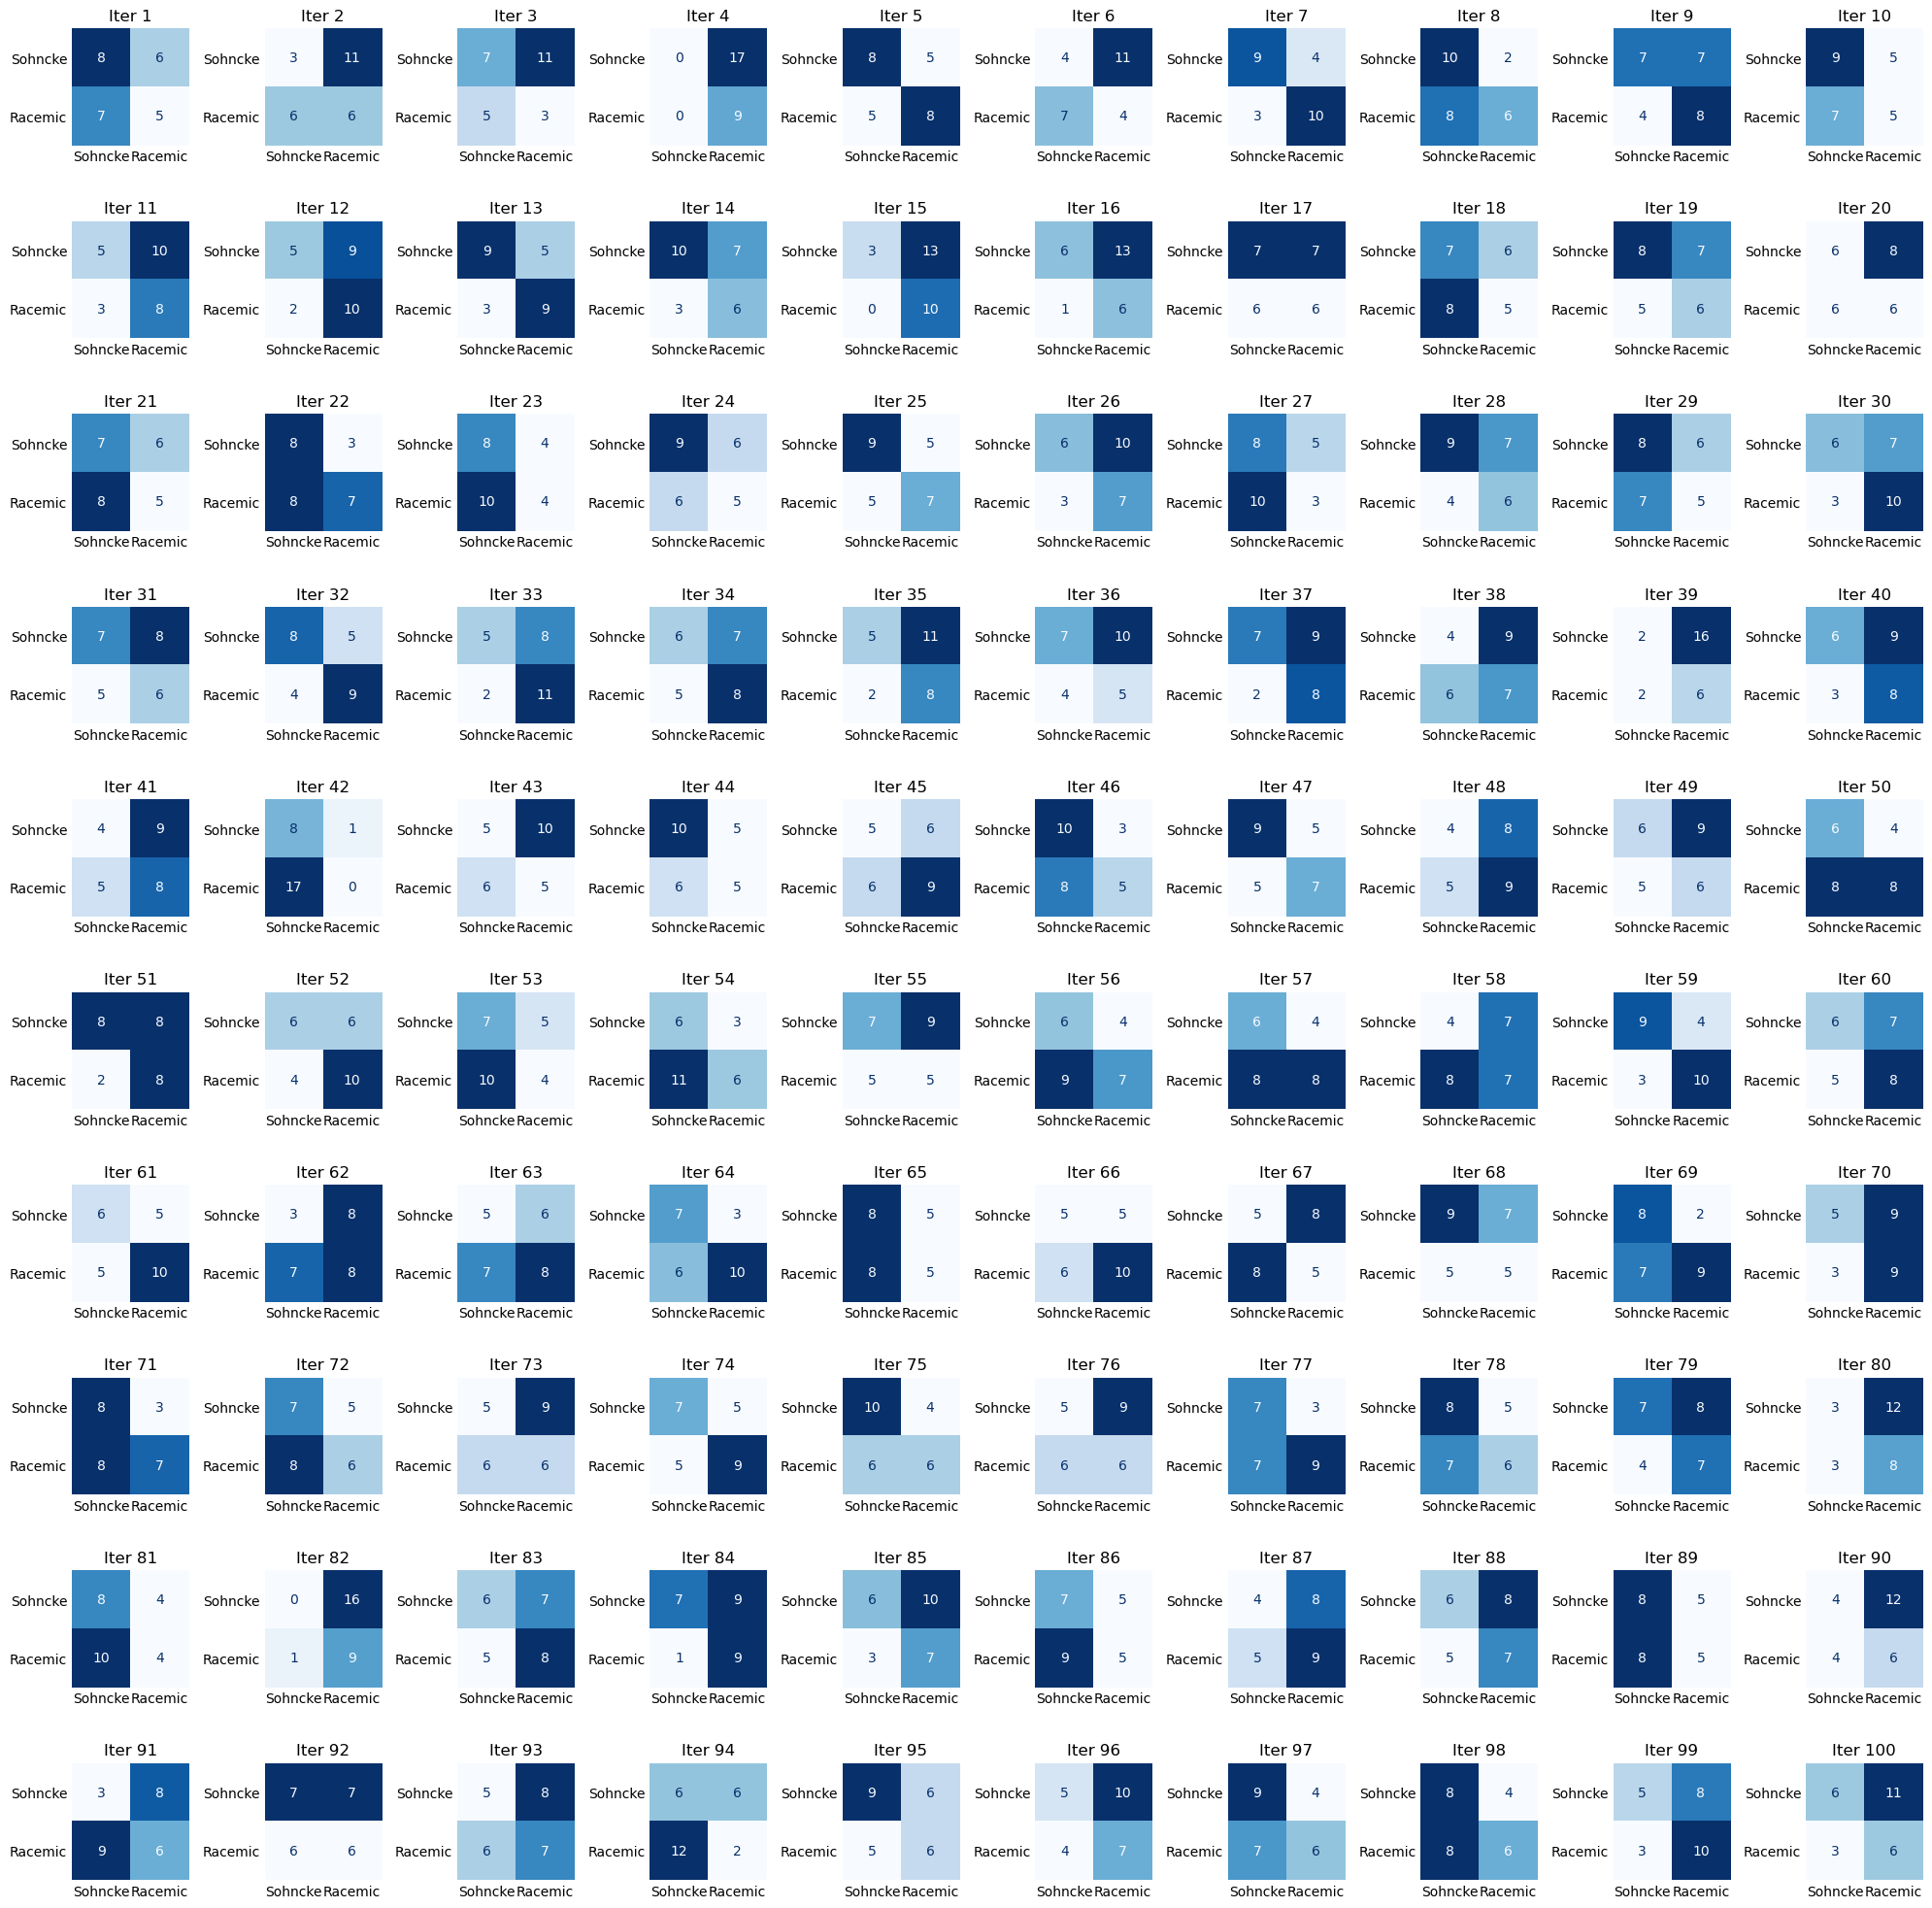


Average accuracy over 100 runs: 0.51

Average Confusion Matrix:
[[6.45 7.09]
 [5.6  6.86]]


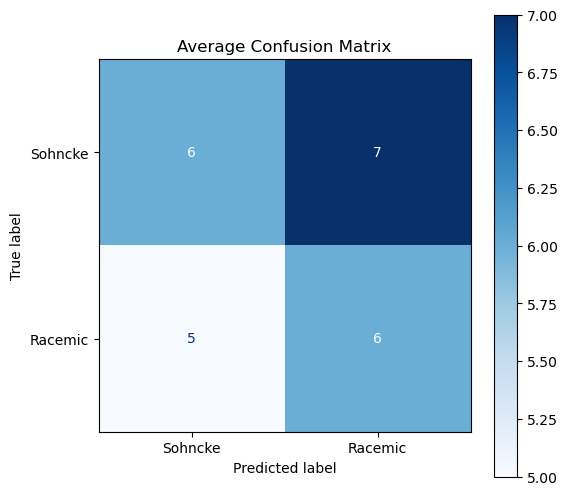

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load data
df = pd.read_csv(r'filtered and normalised all descriptor data.csv')
df_target_0 = df[df['Target'] == 0.0]
df_target_1 = df[df['Target'] == 1.0]
rows_df_target_0 = df_target_0.shape[0]
rows_df_target_1 = df_target_1.shape[0]

# Determine smaller and larger class dataframes
if rows_df_target_0 < rows_df_target_1:
    smaller_df = df_target_0
    larger_df = df_target_1
    smaller_rows = rows_df_target_0
else:
    smaller_df = df_target_1
    larger_df = df_target_0
    smaller_rows = rows_df_target_1

# Initialize variables to track performance
accuracies = []
all_confusion_matrices = []

# Run the model 100 times
for i in range(100):
    # Balance the dataset
    scaled_larger_df = larger_df.sample(n=smaller_rows)
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
    shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
    shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode'])
    feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
    X = np.asarray(feature_df)
    y = np.asarray(shuffled_balanced_cleaned_df['Target'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

    # Define the model pipeline with scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=10000))
    ])

    # Define the parameter grid
    param_grid = {
        'logreg__C': [0.01, 0.1, 1, 10, 100],
        'logreg__penalty': ['l2'],  # You can also try 'l1' if the solver supports it
        'logreg__solver': ['liblinear', 'lbfgs', 'newton-cg', 'sag', 'saga']
    }

    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='accuracy',
        verbose=0
    )

    # Fit GridSearchCV
    grid_search.fit(X_train, y_train)

    # Get the best estimator
    best_estimator = grid_search.best_estimator_

    # Predict on the test set
    y_pred = best_estimator.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    # Get confusion matrix and store it
    confusion_mat = confusion_matrix(y_test, y_pred)
    all_confusion_matrices.append(confusion_mat)

# Plot all confusion matrices in a single figure
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()

for i, cm in enumerate(all_confusion_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sohncke", "Racemic"])
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=axes[i], colorbar=False)
    axes[i].set_title(f'Iter {i+1}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='both', which='both', length=0)
    for spine in axes[i].spines.values():
        spine.set_visible(False)

# Hide the extra subplots
for i in range(len(all_confusion_matrices), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Calculate and print average accuracy
average_accuracy = np.mean(accuracies)
print(f"\nAverage accuracy over 100 runs: {average_accuracy:.2f}")

# Calculate and print average confusion matrix
average_confusion_matrix = np.mean(all_confusion_matrices, axis=0)
print("\nAverage Confusion Matrix:")
print(average_confusion_matrix)

# Plot the average confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=average_confusion_matrix.astype(int), display_labels=["Sohncke", "Racemic"])
disp_avg.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
ax.set_title('Average Confusion Matrix')
plt.show()
